# Agent Hard Benchmark Pipeline Demo

This notebook demonstrates the complete workflow of our benchmark filtering pipeline using tau-bench as an example.

The pipeline consists of the following steps:
1. **Data Loading** - Load benchmark data and model responses
2. **Step 1: Rule-based Filtering** - Filter problematic questions using rules
3. **Step 2: LLM-as-Judge Filtering** - Use LLM to assess question quality
4. **Step 3: Comprehensive Filtering** - Apply comprehensive rule-based filters
5. **Step 4: Diversity Selection** - Select diverse question subset based on semantic embeddings
6. **Metrics Computation** - Calculate separability, diversity, IRT metrics after each step

## 0. Environment Setup and Imports

In [1]:
import sys
import os
import json
import logging
from datetime import datetime
from typing import Dict, List

# Add src to path
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('')), "src"))

# Import pipeline modules
from main import BenchmarkFilteringPipeline
from src.utils.types import Benchmark, UniqueQuestionID
from src.utils import group_responses_by_question

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

print("✓ Imports completed")

/eic/data/binfei_gpu6/miniconda3/envs/agenthard/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/eic/data/binfei_gpu6/miniconda3/envs/agenthard/lib/python3.11/site-packages/pydantic/_internal/_fields.py:160: UserWarning: Field "model_responses" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
/eic/data/binfei_gpu6/miniconda3/envs/agenthard/lib/python3.11/site-packages/pydantic/_internal/_fields.py:160: UserWarning: Field "model_name" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(


✓ Imports completed


## 1. Initialize Pipeline

Configure pipeline parameters including:
- Target benchmark: tau-bench
- LLM model: for quality assessment
- Embedding model: for diversity computation
- Other parameters: batch size, number of processes, etc.

In [2]:
# Pipeline configuration
config = {
    "target_benchmark": ["tau-bench"],  # Specify tau-bench
    "llm_model": "google/gemini-2.5-pro-thinking-on",  # LLM judge model
    "llm_filter_mode": "specific",  # Use benchmark-specific filtering
    "skip_scoring": True,  # Whether to skip scoring step
    "embedding_model": "Qwen/Qwen3-Embedding-8B",  # Embedding model for diversity
    "embedding_batch_size": 8,
    "num_proc": 32,  # Number of parallel processes
    "skip_measurement": False,  # Whether to skip metric computation
    "csv_filename": "demo_filtering_summary.csv",
    "report_filename": "demo_report.csv",
}

# Initialize pipeline
pipeline = BenchmarkFilteringPipeline(config)

print(f"✓ Pipeline initialized")
print(f"  - Target benchmark: {config['target_benchmark']}")
print(f"  - LLM model: {config['llm_model']}")
print(f"  - Embedding model: {config['embedding_model']}")

2025-12-02 22:26:05,292 - src.benchmark_specific_filters.base_filter - INFO - Initialized DrafterBench filter
2025-12-02 22:26:05,293 - src.benchmark_specific_filters.base_filter - INFO - Initialized MultiChallenge filter
2025-12-02 22:26:05,294 - src.benchmark_specific_filters.base_filter - INFO - Initialized ACEBench filter
2025-12-02 22:26:05,294 - src.benchmark_specific_filters.base_filter - INFO - Initialized ComplexFuncBench filter
2025-12-02 22:26:05,295 - src.benchmark_specific_filters.base_filter - INFO - Initialized BFCL filter
2025-12-02 22:26:05,296 - src.benchmark_specific_filters.base_filter - INFO - Initialized BFCL_V4 filter
2025-12-02 22:26:05,296 - src.benchmark_specific_filters.base_filter - INFO - Initialized NexusBench filter
2025-12-02 22:26:05,297 - src.benchmark_specific_filters.base_filter - INFO - Initialized TAU Bench filter
2025-12-02 22:26:05,297 - src.benchmark_specific_filters.base_filter - INFO - Initialized TAU2 Bench filter
2025-12-02 22:26:05,368 - se

✓ Pipeline initialized
  - Target benchmark: ['tau-bench']
  - LLM model: google/gemini-2.5-pro-thinking-on
  - Embedding model: Qwen/Qwen3-Embedding-8B


## 2. Data Loading

Load tau-bench raw data including:
- Question definitions
- Model responses from multiple models
- Ground truth annotations

In [3]:
# Load all benchmark data
all_responses = pipeline._load_benchmark_data()

print(f"  - Total samples: {len(all_responses):,}")

# Examine the structure of the first sample
if all_responses:
    print("\nSample data structure:")
    sample = all_responses[0]
    print(f"  - Benchmark: {sample['benchmark_name']}")
    print(f"  - Model: {sample['model_name']}")
    print(f"  - Task: {sample.get('task_name', 'N/A')}")
    print(f"  - Question ID: {sample['meta']['id']}")
    print(f"  - Keys: {list(sample.keys())}")

2025-12-02 22:26:13,102 - main - INFO - Loading benchmark data...
2025-12-02 22:26:13,103 - main - INFO - Loading only target benchmark: ['tau-bench']
2025-12-02 22:26:13,104 - src.data_loader - INFO - Loading benchmark data from benchmark
2025-12-02 22:26:13,105 - src.data_loader - INFO - Loading target benchmarks: ['tau-bench']
2025-12-02 22:26:13,106 - src.data_loader - INFO - Loading benchmark: tau-bench
2025-12-02 22:26:13,142 - src.data_loader - INFO - Loaded 165 samples from benchmark/tau-bench-evaluation/gpt-oss-120b.jsonl
2025-12-02 22:26:13,172 - src.data_loader - INFO - Loaded 165 samples from benchmark/tau-bench-evaluation/DeepSeek-V3.2-Exp-thinking-off.jsonl
2025-12-02 22:26:13,201 - src.data_loader - INFO - Loaded 165 samples from benchmark/tau-bench-evaluation/Kimi-K2-Instruct.jsonl
2025-12-02 22:26:13,221 - src.data_loader - INFO - Loaded 165 samples from benchmark/tau-bench-evaluation/gpt-4o-20240806.jsonl
2025-12-02 22:26:13,503 - src.data_loader - INFO - Loaded 165 s

  - Total samples: 6,435

Sample data structure:
  - Benchmark: tau-bench
  - Model: gpt-oss-120b
  - Task: airline
  - Question ID: airline_0
  - Keys: ['model_path', 'user_model_path', 'benchmark_name', 'task_name', 'sampling_params', 'user_sampling_params', 'messages', 'eval_result', 'meta', 'model_name']


## 3. Data Preprocessing

Group data by question and filter illegal data:
- Remove duplicate responses
- Ensure each question has responses from all models
- Filter out models with incomplete responses

In [4]:
# Get all questions
pipeline.all_questions = pipeline._get_all_questions_from_loader()

# Load human-labeled ground truth
pipeline.human_labelled_details = pipeline.data_loader.load_human_labelled_ground_truth(
    config.get("target_benchmark")
)
current_human_labelled = set(pipeline.human_labelled_details.keys())

# Group responses by question
responses_by_question = group_responses_by_question(all_responses)
print(f"\nAfter grouping by question:")
print(f"  - Total questions: {len(responses_by_question)}")

# Filter illegal data
responses_by_question = pipeline.filter_illegal_data(responses_by_question)
print(f"\nAfter filtering illegal data:")
print(f"  - Valid questions: {len(responses_by_question)}")
print(f"  - Human-labeled questions: {len(current_human_labelled)}")

# Store initial baseline
pipeline.initial_baseline_ids = set(responses_by_question.keys())

2025-12-02 22:26:26,948 - src.data_loader - INFO - Loading human labelled ground truth data...
2025-12-02 22:26:26,950 - src.data_loader - INFO - Loaded 32 total labelled questions for tau-bench
2025-12-02 22:26:27,013 - root - INFO - Filtered 0/6435 duplicated responses.
2025-12-02 22:26:27,019 - root - INFO - Filtered model {'DeepSeek-V3.1-thinking-on', 'grok-4-fast-thinking-off', 'Qwen3-32B', 'grok-4', 'Qwen3-8B', 'DeepSeek-V3.1-Terminus-thinking-on', 'DeepSeek-V3.1-thinking-off', 'DeepSeek-V3.1-Terminus-thinking-off', 'grok-4-fast-thinking-on', 'gpt-4o-20240806'} for benchmark tau-bench to maintain consistency cross all benchmarks.
2025-12-02 22:26:27,021 - root - INFO - Filtered 1650/6435 responses to maintain consistency cross all benchmarks.



After grouping by question:
  - Total questions: 165

After filtering illegal data:
  - Valid questions: 165
  - Human-labeled questions: 32


## 4. Initial Dataset Metrics

Before filtering, calculate baseline metrics for the original dataset:
- **Separability**: Model performance discrimination
- **Diversity**: Semantic diversity of questions
- **IRT**: Item Response Theory metrics
- **Rank Stability**: Ranking stability

In [ ]:
# Calculate metrics for initial dataset
pipeline.compute_and_log_metrics(
    passed_responses=responses_by_question,
    input_ids=pipeline.initial_baseline_ids,
    phase="initial",
    human_labelled_questions=current_human_labelled,
    baseline_source=responses_by_question,
    no_system_prompt=False,
)

print(f"\nInitial metrics summary:")
initial_metrics = pipeline.metrics_summary["original"]
print(f"  - Total questions: {initial_metrics['total_num']}")
if initial_metrics.get('separability'):
    sep_dict = initial_metrics['separability'][0]
    if isinstance(sep_dict, dict) and 'tau-bench' in sep_dict:
        print(f"  - Separability: {sep_dict['tau-bench']:.4f}")
if initial_metrics.get('diversity'):
    div_val = initial_metrics['diversity']
    if isinstance(div_val, dict) and 'tau-bench' in div_val:
        print(f"  - Diversity: {div_val['tau-bench']:.4f}")
    elif isinstance(div_val, (int, float)):
        print(f"  - Diversity: {div_val:.4f}")

2025-12-02 22:26:27,030 - main - INFO - 
=== Computing Metrics for INITIAL ===
2025-12-02 22:26:27,032 - main - INFO - Recording filter summary for phase: initial
2025-12-02 22:26:27,037 - main - INFO - Filtering summary saved to: demo_filtering_summary.csv
2025-12-02 22:26:32,747 - main - INFO - Benchmark separability before filtering: {
  "tau-bench": 0.5784615384615385
}
2025-12-02 22:26:38,026 - main - INFO - Benchmark separability before filtering: {
  "tau-bench": 0.5815384615384616
}
2025-12-02 22:26:43,296 - main - INFO - Benchmark separability before filtering: {
  "tau-bench": 0.5876923076923077
}
2025-12-02 22:26:43,299 - main - INFO - Benchmark IRT discrimination before filtering: 0.0279
2025-12-02 22:26:43,858 - main - INFO - Benchmark semantic diversity before filtering: {
  "tau-bench": 0.2001953125
}
2025-12-02 22:26:43,859 - main - INFO - Creating visualization: Original Dataset
2025-12-02 22:26:44,844 - main - INFO - Saved plot: pipeline_results/plots/original_perform


Initial metrics summary:
  - Total questions: 165
  - Separability: 0.5785
  - Diversity: 0.2002


## 5. Step 1: Benchmark-Specific Rule-Based Filtering

Apply tau-bench specific rules, such as:
- Check if question format is correct
- Verify required fields exist
- Filter obviously problematic samples

In [6]:
logger.info("Step 1: Benchmark-specific filtering")

# Run benchmark-specific filtering
step1_passed, step1_dropped = pipeline._run_benchmark_specific_filtering(
    responses_by_question
)

print(f"\n✓ Step 1 completed")
print(f"  - Passed questions: {len(step1_passed)}")
print(f"  - Filtered questions: {len(step1_dropped)}")
print(f"  - Retention rate: {len(step1_passed) / len(responses_by_question) * 100:.1f}%")

# Calculate metrics after step1
pipeline.compute_and_log_metrics(
    passed_responses=step1_passed,
    input_ids=set(responses_by_question.keys()),
    phase="step1",
    human_labelled_questions=current_human_labelled,
    baseline_source=responses_by_question,
)

# Update current dataset and human-labeled set
current_responses = step1_passed
current_human_labelled = current_human_labelled & set(step1_passed.keys())

# Display metric changes
step1_metrics = pipeline.metrics_summary["step1"]
print(f"\nStep 1 metric changes:")
if step1_metrics.get('separability') and initial_metrics.get('separability'):
    initial_sep = initial_metrics['separability'][0].get('tau-bench') if isinstance(initial_metrics['separability'][0], dict) else None
    step1_sep = step1_metrics['separability'][0].get('tau-bench') if isinstance(step1_metrics['separability'][0], dict) else None
    if initial_sep is not None and step1_sep is not None:
        print(f"  - Separability: {initial_sep:.4f} → {step1_sep:.4f}")
if step1_metrics.get('diversity') and initial_metrics.get('diversity'):
    initial_div = initial_metrics['diversity'].get('tau-bench') if isinstance(initial_metrics['diversity'], dict) else initial_metrics['diversity']
    step1_div = step1_metrics['diversity'].get('tau-bench') if isinstance(step1_metrics['diversity'], dict) else step1_metrics['diversity']
    if initial_div is not None and step1_div is not None:
        print(f"  - Diversity: {initial_div:.4f} → {step1_div:.4f}")

2025-12-02 22:26:48,136 - __main__ - INFO - Step 1: Benchmark-specific filtering
2025-12-02 22:26:48,137 - main - INFO - Step 1: Applying benchmark-specific filtering for benchmarks with specific filters...
2025-12-02 22:26:48,138 - main - INFO - Applying tau-bench-specific filtering to 4785 samples
2025-12-02 22:26:48,138 - src.benchmark_specific_filters.tau_bench_filter - INFO - Applying TAU Bench-specific filtering to 4785 samples
2025-12-02 22:27:00,533 - src.benchmark_specific_filters.tau_bench_filter - INFO - Unfiltered airline-airline_3: role confusion rate 0.038 < 0.2
2025-12-02 22:27:00,542 - src.benchmark_specific_filters.tau_bench_filter - INFO - Unfiltered airline-airline_16: role confusion rate 0.077 < 0.2
2025-12-02 22:27:00,544 - src.benchmark_specific_filters.tau_bench_filter - INFO - Unfiltered airline-airline_17: role confusion rate 0.038 < 0.2
2025-12-02 22:27:00,546 - src.benchmark_specific_filters.tau_bench_filter - INFO - Unfiltered airline-airline_20: role confus

Saved 4693 samples to filtered_datasets/unified_pruned_TAU Bench-Specific Filter.jsonl


2025-12-02 22:27:04,441 - main - INFO - tau-bench: 4693 passed, 92 dropped
2025-12-02 22:27:04,480 - main - INFO - Step 1 completed: 4,693 samples passed, 92 samples dropped
2025-12-02 22:27:04,482 - main - INFO - 
=== Computing Metrics for STEP1 ===
2025-12-02 22:27:04,483 - main - INFO - Recording filter summary for phase: step1
2025-12-02 22:27:04,485 - root - INFO - ==================== Retention ratio after step1 ====================
2025-12-02 22:27:04,485 - root - INFO - Overall retention: 165/165 = 100.00%
2025-12-02 22:27:04,486 - root - INFO - retail: 100.00%
2025-12-02 22:27:04,486 - root - INFO - airline: 100.00%
2025-12-02 22:27:04,490 - main - INFO - Filtering summary saved to: demo_filtering_summary.csv


Saved 4693 samples to filtered_datasets/tau-bench_pruned_TAU Bench-Specific Filter.jsonl
Saved filtered results:
  - Unified dataset: filtered_datasets/unified_pruned_TAU Bench-Specific Filter.jsonl
  - benchmark_specific: filtered_datasets/tau-bench_pruned_TAU Bench-Specific Filter.jsonl

✓ Step 1 completed
  - Passed questions: 165
  - Filtered questions: 23
  - Retention rate: 100.0%


2025-12-02 22:27:09,779 - main - INFO - Benchmark separability after step1: {
  "tau-bench": 0.5138461538461538
}
2025-12-02 22:27:15,072 - main - INFO - Benchmark separability after step1: {
  "tau-bench": 0.5076923076923077
}
2025-12-02 22:27:20,348 - main - INFO - Benchmark separability after step1: {
  "tau-bench": 0.5107692307692308
}
2025-12-02 22:27:20,351 - main - INFO - Benchmark IRT discrimination after step1: 0.0279
2025-12-02 22:27:20,911 - main - INFO - Benchmark semantic diversity for step1: {
  "tau-bench": 0.2001953125
}
2025-12-02 22:27:20,912 - main - INFO - Creating visualization: After Step 1 (Rule-based Filtering)
2025-12-02 22:27:21,873 - main - INFO - Saved plot: pipeline_results/plots/step1_filtered_performance_tau-bench.png
2025-12-02 22:27:21,874 - main - INFO - Creating model agreement heatmap for tau-bench
2025-12-02 22:27:25,206 - main - INFO - Saved agreement heatmap: pipeline_results/plots/step1_filtered_performance_tau-bench_agreement_heatmap.png
2025-12

Total tasks for BASELINE:  165


2025-12-02 22:27:30,521 - main - INFO - Benchmark separability baseline (vs. step1): {
  "tau-bench": 0.6246153846153846
}
2025-12-02 22:27:35,808 - main - INFO - Benchmark separability baseline (vs. step1): {
  "tau-bench": 0.5784615384615385
}
2025-12-02 22:27:41,115 - main - INFO - Benchmark separability baseline (vs. step1): {
  "tau-bench": 0.6246153846153846
}
2025-12-02 22:27:41,674 - main - INFO - Benchmark diversity baseline (vs. step1): {
  "tau-bench": 0.2001953125
}
2025-12-02 22:27:41,676 - main - INFO - Benchmark IRT baseline (vs. step1): 0.0279
2025-12-02 22:27:41,677 - main - INFO - Creating visualization: Baseline (Random Sampling)
2025-12-02 22:27:42,637 - main - INFO - Saved plot: pipeline_results/plots/step1_baseline_performance_tau-bench.png
2025-12-02 22:27:42,638 - main - INFO - Creating model agreement heatmap for tau-bench
2025-12-02 22:27:45,903 - main - INFO - Saved agreement heatmap: pipeline_results/plots/step1_baseline_performance_tau-bench_agreement_heatm


Step 1 metric changes:
  - Separability: 0.5785 → 0.5138
  - Diversity: 0.2002 → 0.2002


## 6. Step 2: LLM-as-Judge Filtering

Use LLM to judge the quality of each question, including:
- Universal Filter: General quality checks
- Benchmark-Specific Filter: Tau-bench specific checks
- Scoring (Optional): Score questions

In [8]:
logger.info("Step 2: LLM-as-Judge filtering")

# Run LLM judge filtering
step2_result = pipeline._run_llm_judge(current_responses)

# Get passed questions
step1_passed_qids = list(current_responses.keys())
step2_passed = {
    qid: responses_by_question[qid]
    for qid in step1_passed_qids
    if not pipeline._is_question_flawed(step2_result[qid])
}

print(f"\n Step 2 completed")
print(f"  - Passed questions: {len(step2_passed)}")
print(f"  - Filtered questions: {len(step1_passed) - len(step2_passed)}")
print(f"  - Retention rate (vs step1): {len(step2_passed) / len(step1_passed) * 100:.1f}%")

2025-12-02 22:33:59,829 - __main__ - INFO - Step 2: LLM-as-Judge filtering
2025-12-02 22:34:12,427 - src.llm_judge_filtering - INFO - Running benchmark-specific LLM-judge filtering on 165 questions
2025-12-02 22:34:12,428 - src.llm_judge_filtering - INFO - Using multiprocessing with 32 processes
Processing questions (multiprocessing): 100%|██████████| 165/165 [05:29<00:00,  2.00s/it]



✓ Step 2 completed
  - Passed questions: 125
  - Filtered questions: 40
  - Retention rate (vs step1): 75.8%


In [9]:
# Calculate metrics after step2
pipeline.compute_and_log_metrics(
    passed_responses=step2_passed,
    input_ids=set(step1_passed_qids),
    phase="step2",
    human_labelled_questions=current_human_labelled,
    baseline_source=responses_by_question,
)

# Update current dataset
current_responses = step2_passed
current_human_labelled = current_human_labelled & set(step2_passed.keys())

# Display metric changes
step2_metrics = pipeline.metrics_summary["step2"]
print(f"\nStep 2 metric changes:")
if step2_metrics.get('separability') and step1_metrics.get('separability'):
    step1_sep = step1_metrics['separability'][0].get('tau-bench') if isinstance(step1_metrics['separability'][0], dict) else None
    step2_sep = step2_metrics['separability'][0].get('tau-bench') if isinstance(step2_metrics['separability'][0], dict) else None
    if step1_sep is not None and step2_sep is not None:
        print(f"  - Separability: {step1_sep:.4f} → {step2_sep:.4f}")
if step2_metrics.get('diversity') and step1_metrics.get('diversity'):
    step1_div = step1_metrics['diversity'].get('tau-bench') if isinstance(step1_metrics['diversity'], dict) else step1_metrics['diversity']
    step2_div = step2_metrics['diversity'].get('tau-bench') if isinstance(step2_metrics['diversity'], dict) else step2_metrics['diversity']
    if step1_div is not None and step2_div is not None:
        print(f"  - Diversity: {step1_div:.4f} → {step2_div:.4f}")

2025-12-02 22:40:00,568 - main - INFO - 
=== Computing Metrics for STEP2 ===
2025-12-02 22:40:00,570 - main - INFO - Recording filter summary for phase: step2
2025-12-02 22:40:00,573 - root - INFO - ==================== Retention ratio after step2 ====================
2025-12-02 22:40:00,573 - root - INFO - Overall retention: 125/165 = 75.76%
2025-12-02 22:40:00,574 - root - INFO - retail: 86.09%
2025-12-02 22:40:00,574 - root - INFO - airline: 52.00%
2025-12-02 22:40:00,580 - main - INFO - Filtering summary saved to: demo_filtering_summary.csv
2025-12-02 22:40:05,248 - main - INFO - Benchmark separability after step2: {
  "tau-bench": 0.6553846153846155
}
2025-12-02 22:40:09,813 - main - INFO - Benchmark separability after step2: {
  "tau-bench": 0.6030769230769231
}
2025-12-02 22:40:14,437 - main - INFO - Benchmark separability after step2: {
  "tau-bench": 0.6030769230769231
}
2025-12-02 22:40:14,440 - main - INFO - Benchmark IRT discrimination after step2: 0.0423
2025-12-02 22:40:1

Total tasks for BASELINE:  125


2025-12-02 22:40:23,664 - main - INFO - Benchmark separability baseline (vs. step2): {
  "tau-bench": 0.5507692307692308
}
2025-12-02 22:40:28,370 - main - INFO - Benchmark separability baseline (vs. step2): {
  "tau-bench": 0.5507692307692308
}
2025-12-02 22:40:33,089 - main - INFO - Benchmark separability baseline (vs. step2): {
  "tau-bench": 0.5507692307692308
}
2025-12-02 22:40:33,410 - main - INFO - Benchmark diversity baseline (vs. step2): {
  "tau-bench": 0.1978759765625
}
2025-12-02 22:40:33,412 - main - INFO - Benchmark IRT baseline (vs. step2): 0.0305
2025-12-02 22:40:33,413 - main - INFO - Creating visualization: Baseline (Random Sampling)
2025-12-02 22:40:34,355 - main - INFO - Saved plot: pipeline_results/plots/step2_baseline_performance_tau-bench.png
2025-12-02 22:40:34,355 - main - INFO - Creating model agreement heatmap for tau-bench
2025-12-02 22:40:38,050 - main - INFO - Saved agreement heatmap: pipeline_results/plots/step2_baseline_performance_tau-bench_agreement_he


Step 2 metric changes:
  - Separability: 0.5138 → 0.6554
  - Diversity: 0.2002 → 0.1713


## 6. Step 3: Comprehensive Rule-Based Filtering

Apply more comprehensive rule-based filters including:
- Statistical feature checks
- Data quality validation
- Consistency checks

In [10]:
logger.info("Step 3: Comprehensive rule-based filtering")

# Run comprehensive filtering
step3_passed = pipeline._run_comprehensive_filtering(
    current_responses, responses_by_question
)

print(f"\n✓ Step 3 completed")
print(f"  - Passed questions: {len(step3_passed)}")
print(f"  - Filtered questions: {len(current_responses) - len(step3_passed)}")


2025-12-02 22:41:32,756 - __main__ - INFO - Step 3: Comprehensive rule-based filtering
2025-12-02 22:41:32,757 - main - INFO - Applying comprehensive rule-based filtering...
2025-12-02 22:41:32,880 - src.comprehensive_rule_filtering - INFO - Filtered 10 non-discrimination questions
2025-12-02 22:41:32,881 - src.comprehensive_rule_filtering - INFO - Filtered 1 too-easy questions
2025-12-02 22:41:32,884 - main - INFO - Step 4 completed: 115 samples passed



✓ Step 3 completed
  - Passed questions: 115
  - Filtered questions: 10


In [11]:
# Calculate metrics after step3

pipeline.compute_and_log_metrics(
    passed_responses=step3_passed,
    input_ids=set(current_responses.keys()),
    phase="step3",
    human_labelled_questions=current_human_labelled,
    baseline_source=responses_by_question,
)

# Update current dataset
current_responses = step3_passed
current_human_labelled = current_human_labelled & set(step3_passed.keys())

# Display metric changes
step3_metrics = pipeline.metrics_summary["step3"]
print(f"\nStep 3 metric changes:")
if step3_metrics.get('separability') and step2_metrics.get('separability'):
    step2_sep = step2_metrics['separability'][0].get('tau-bench') if isinstance(step2_metrics['separability'][0], dict) else None
    step3_sep = step3_metrics['separability'][0].get('tau-bench') if isinstance(step3_metrics['separability'][0], dict) else None
    if step2_sep is not None and step3_sep is not None:
        print(f"  - Separability: {step2_sep:.4f} → {step3_sep:.4f}")
if step3_metrics.get('diversity') and step2_metrics.get('diversity'):
    step2_div = step2_metrics['diversity'].get('tau-bench') if isinstance(step2_metrics['diversity'], dict) else step2_metrics['diversity']
    step3_div = step3_metrics['diversity'].get('tau-bench') if isinstance(step3_metrics['diversity'], dict) else step3_metrics['diversity']
    if step2_div is not None and step3_div is not None:
        print(f"  - Diversity: {step2_div:.4f} → {step3_div:.4f}")

2025-12-02 22:41:36,114 - main - INFO - 
=== Computing Metrics for STEP3 ===
2025-12-02 22:41:36,115 - main - INFO - Recording filter summary for phase: step3
2025-12-02 22:41:36,117 - root - INFO - ==================== Retention ratio after step3 ====================
2025-12-02 22:41:36,118 - root - INFO - Overall retention: 115/165 = 69.70%
2025-12-02 22:41:36,118 - root - INFO - retail: 80.00%
2025-12-02 22:41:36,119 - root - INFO - airline: 46.00%
2025-12-02 22:41:36,123 - main - INFO - Filtering summary saved to: demo_filtering_summary.csv
2025-12-02 22:41:40,819 - main - INFO - Benchmark separability after step3: {
  "tau-bench": 0.6707692307692308
}
2025-12-02 22:41:45,527 - main - INFO - Benchmark separability after step3: {
  "tau-bench": 0.676923076923077
}
2025-12-02 22:41:50,235 - main - INFO - Benchmark separability after step3: {
  "tau-bench": 0.6369230769230769
}
2025-12-02 22:41:50,237 - main - INFO - Benchmark IRT discrimination after step3: 0.0375
2025-12-02 22:41:50

Total tasks for BASELINE:  115


2025-12-02 22:41:59,850 - main - INFO - Benchmark separability baseline (vs. step3): {
  "tau-bench": 0.5969230769230769
}
2025-12-02 22:42:04,677 - main - INFO - Benchmark separability baseline (vs. step3): {
  "tau-bench": 0.5876923076923077
}
2025-12-02 22:42:09,395 - main - INFO - Benchmark separability baseline (vs. step3): {
  "tau-bench": 0.6369230769230769
}
2025-12-02 22:42:09,666 - main - INFO - Benchmark diversity baseline (vs. step3): {
  "tau-bench": 0.19580078125
}
2025-12-02 22:42:09,668 - main - INFO - Benchmark IRT baseline (vs. step3): 0.0253
2025-12-02 22:42:09,669 - main - INFO - Creating visualization: Baseline (Random Sampling)
2025-12-02 22:42:10,670 - main - INFO - Saved plot: pipeline_results/plots/step3_baseline_performance_tau-bench.png
2025-12-02 22:42:10,670 - main - INFO - Creating model agreement heatmap for tau-bench
2025-12-02 22:42:14,084 - main - INFO - Saved agreement heatmap: pipeline_results/plots/step3_baseline_performance_tau-bench_agreement_heat


Step 3 metric changes:
  - Separability: 0.6554 → 0.6708
  - Diversity: 0.1713 → 0.1677


## 8. Final Results Summary

Display the filtering effectiveness and metric changes throughout the entire pipeline


Pipeline Complete Workflow Metrics Comparison
               Phase  Questions  Separability  Diversity
            Original        165      0.578462   0.200195
  Step1: Rule Filter        165      0.513846   0.200195
   Step2: LLM Filter        125      0.655385   0.171265
Step3: Comprehensive        115      0.670769   0.167725


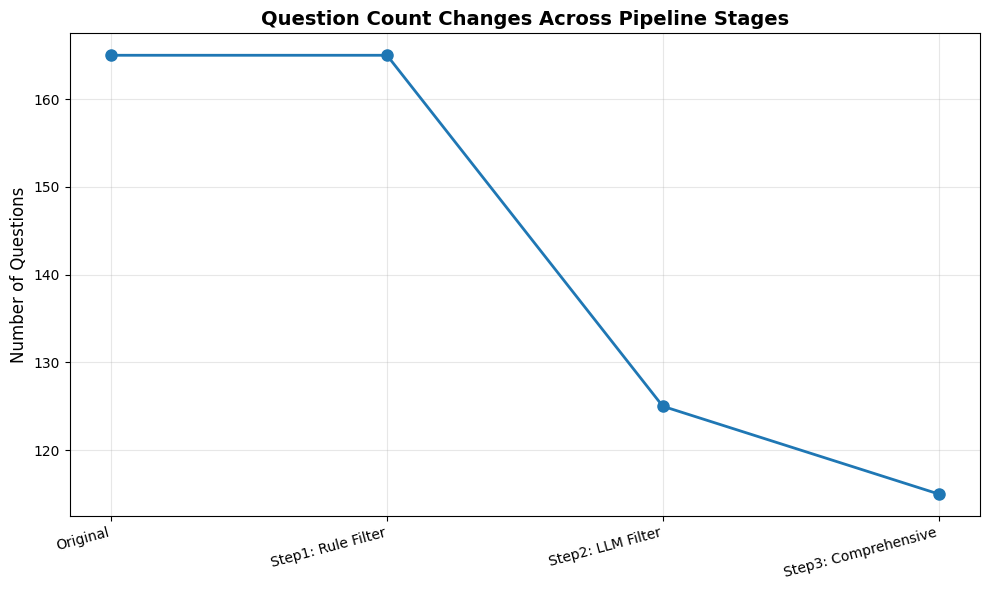


Summary:
  - Initial questions: 165
  - Final questions: 115
  - Overall retention rate: 69.7%
  - Filtered out: 50 questions


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Create metrics comparison table
phases = ['initial', 'step1', 'step2', 'step3',]
phase_names = ['Original', 'Step1: Rule Filter', 'Step2: LLM Filter', 'Step3: Comprehensive',]

metrics_data = []
for phase in phases:
    # Use 'original' for 'initial' phase
    metrics_key = 'original' if phase == 'initial' else phase
    metrics = pipeline.metrics_summary.get(metrics_key, {})
    
    # Extract separability value for tau-bench
    sep_value = None
    if metrics.get('separability'):
        sep_list = metrics['separability']
        if isinstance(sep_list, list) and len(sep_list) > 0:
            sep_dict = sep_list[0]
            if isinstance(sep_dict, dict):
                sep_value = sep_dict.get('tau-bench')
    
    # Extract diversity value for tau-bench
    div_value = None
    if metrics.get('diversity'):
        div_data = metrics['diversity']
        if isinstance(div_data, dict):
            div_value = div_data.get('tau-bench')
        elif isinstance(div_data, (int, float)):
            div_value = div_data
    
    metrics_data.append({
        'Phase': phase_names[phases.index(phase)],
        'Questions': metrics.get('total_num', 0),
        'Separability': sep_value,
        'Diversity': div_value,
    })

df_metrics = pd.DataFrame(metrics_data)
print("\n" + "="*80)
print("Pipeline Complete Workflow Metrics Comparison")
print("="*80)
print(df_metrics.to_string(index=False))

# Visualize question count changes
plt.figure(figsize=(10, 6))
plt.plot(range(len(phases)), df_metrics['Questions'], marker='o', linewidth=2, markersize=8)
plt.xticks(range(len(phases)), phase_names, rotation=15, ha='right')
plt.ylabel('Number of Questions', fontsize=12)
plt.title('Question Count Changes Across Pipeline Stages', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate overall retention rate
initial_count = df_metrics.iloc[0]['Questions']
final_count = df_metrics.iloc[-1]['Questions']
retention_rate = final_count / initial_count * 100

print(f"\nSummary:")
print(f"  - Initial questions: {initial_count}")
print(f"  - Final questions: {final_count}")
print(f"  - Overall retention rate: {retention_rate:.1f}%")
print(f"  - Filtered out: {initial_count - final_count} questions")